# torch.nn
torch.nn 是 PyTorch 中用于构建神经网络的模块。
- 它提供了一系列的类和函数，用于定义和训练神经网络。
- torch.nn 包含了各种层（如全连接层、卷积层、循环层等）、激活函数、损失函数、优化器等，这些组件可以组合起来构建复杂的神经网络模型。

1. 模块（Modules）
torch.nn 中的模块是构建神经网络的基本单元。每个模块可以是一个层（如全连接层、卷积层等），也可以是一个包含多个层的复杂网络。
- torch.nn.Module：所有神经网络模块的基类。自定义网络时，通常需要继承这个类。
- torch.nn.Linear：全连接层（线性层）。
- torch.nn.Conv2d：二维卷积层。
- torch.nn.RNN：循环神经网络层。
- torch.nn.LSTM：长短期记忆网络层。
- torch.nn.GRU：门控循环单元层。

In [5]:
from IPython.display import Image

## torch.nn.Module

torch.nn.Module 是 PyTorch 中用于构建神经网络的核心类。
- 它是所有神经网络模块的基类，提供了构建和管理神经网络的基本框架。
- 通过继承 torch.nn.Module，你可以定义自己的神经网络模型，并利用 PyTorch 提供的自动求导机制、参数管理等功能。

主要功能
- 参数管理：自动管理模型的参数（torch.nn.Parameter），包括权重和偏置。
- 模块组合：可以将多个模块组合成一个更大的模块，方便构建复杂的网络结构。
- 自动求导：自动处理梯度计算，支持反向传播。
- 状态管理：管理模型的训练状态（如训练模式和评估模式）。

一个典型的 torch.nn.Module 子类通常包含以下部分：
- 初始化方法：__init__ 方法，用于初始化模型的层和参数。
- 前向传播方法：forward 方法，定义了输入数据如何通过网络层进行前向传播。

参数管理：
- 模型的参数可以通过 model.parameters() 获取，这些参数将被优化器使用。
- 模型的参数和子模块可以通过 model.state_dict() 获取，方便保存和加载模型。

训练和评估模式：
- 使用 model.train() 将模型切换到训练模式。
- 使用 model.eval() 将模型切换到评估模式。这会影响某些层的行为，如 Dropout 和 BatchNorm。

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的全连接神经网络
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)  # 输入层到隐藏层
        self.relu = nn.ReLU()        # 激活函数
        self.fc2 = nn.Linear(5, 2)   # 隐藏层到输出层

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建模型
model = SimpleNet()

# 打印模型结构
print(model)

SimpleNet(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=5, out_features=2, bias=True)
)


In [3]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 创建一些虚拟数据
inputs = torch.randn(4, 10)  # 4 个样本，每个样本 10 个特征
labels = torch.tensor([0, 1, 0, 1])  # 真实标签

# 训练模型
for epoch in range(100):  # 训练 100 个 epoch
    optimizer.zero_grad()  # 清零梯度
    outputs = model(inputs)  # 前向传播
    loss = criterion(outputs, labels)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6736
Epoch [20/100], Loss: 0.6501
Epoch [30/100], Loss: 0.6260
Epoch [40/100], Loss: 0.6006
Epoch [50/100], Loss: 0.5735
Epoch [60/100], Loss: 0.5448
Epoch [70/100], Loss: 0.5188
Epoch [80/100], Loss: 0.4918
Epoch [90/100], Loss: 0.4640
Epoch [100/100], Loss: 0.4357


## torch.nn.Linear
torch.nn.Linear 是 PyTorch 中用于创建全连接层（也称为线性层）的类。
- 全连接层是神经网络中最基本的层之一，它对输入数据进行线性变换，通常用于处理一维数据。
- 全连接层的输出是输入数据与权重矩阵的乘积加上偏置项。

torch.nn.Linear(in_features, out_features, bias=True)

- in_features：输入特征的数量，即输入张量的最后一个维度的大小。
- out_features：输出特征的数量，即输出张量的最后一个维度的大小。
- bias：布尔值，如果为 True，则该层会添加一个偏置项；如果为 False，则不添加偏置项。默认为 True。
- weight：权重矩阵，形状为 (out_features,in_features)。
- bias：偏置项，形状为 (out_features,)。

In [2]:
import torch
import torch.nn as nn

# 创建一个全连接层
fc_layer = nn.Linear(in_features=10, out_features=5)

# 打印全连接层的权重和偏置
print(fc_layer)
print("Weight shape:", fc_layer.weight.shape)  # 输出：torch.Size([5, 10])
print("Bias shape:", fc_layer.bias.shape)      # 输出：torch.Size([5])

Linear(in_features=10, out_features=5, bias=True)
Weight shape: torch.Size([5, 10])
Bias shape: torch.Size([5])


In [4]:
import torch
import torch.nn as nn

# 创建一个全连接层
fc_layer = nn.Linear(in_features=10, out_features=5)

# 创建一个输入张量
input_tensor = torch.randn(3, 10)  # 3 个样本，每个样本 10 个特征

# 进行前向传播
output_tensor = fc_layer(input_tensor)

# 打印输出张量
print("Output tensor shape:", output_tensor.shape)  # 输出：torch.Size([3, 5])

Output tensor shape: torch.Size([3, 5])


## torch.nn.Conv2d 

torch.nn.Conv2d 是 PyTorch 中用于创建二维卷积层的类。二维卷积层是卷积神经网络（CNN）中的核心组件，广泛用于图像处理和计算机视觉任务。它通过对输入图像应用多个卷积核（或滤波器）来提取特征。

torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)

参数说明
- in_channels：输入张量的通道数。
- out_channels：输出张量的通道数，即卷积核的数量。
- kernel_size：卷积核的大小，可以是单个整数（表示正方形卷积核）或一个元组（表示矩形卷积核）。
- stride：卷积的步长，默认为 1。
- padding：输入张量的填充大小，默认为 0。
- dilation：卷积核的膨胀率，默认为 1。
- groups：分组卷积的组数，默认为 1。
- bias：布尔值，如果为 True，则该层会添加一个偏置项；如果为 False，则不添加偏置项。默认为 True。
- padding_mode：填充模式，可以是 'zeros'、'reflect'、'replicate' 或 'circular'。默认为 'zeros'。
- device：指定张量存储的设备，默认为 None。
- dtype：指定张量的数据类型，默认为 None。

In [4]:
import torch
import torch.nn as nn

# 创建一个二维卷积层
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

# 打印卷积层的权重和偏置
print("Weight shape:", conv_layer.weight.shape)  # 输出：torch.Size([16, 3, 3, 3])
print("Bias shape:", conv_layer.bias.shape)      # 输出：torch.Size([16])

Weight shape: torch.Size([16, 3, 3, 3])
Bias shape: torch.Size([16])


In [5]:
import torch
import torch.nn as nn

# 创建一个二维卷积层
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

# 创建一个输入张量
input_tensor = torch.randn(4, 3, 32, 32)  # 4 个样本，每个样本 3 个通道，大小为 32x32

# 进行前向传播
output_tensor = conv_layer(input_tensor)

# 打印输出张量
print("Output tensor shape:", output_tensor.shape)  # 输出：torch.Size([4, 16, 32, 32])

Output tensor shape: torch.Size([4, 16, 32, 32])


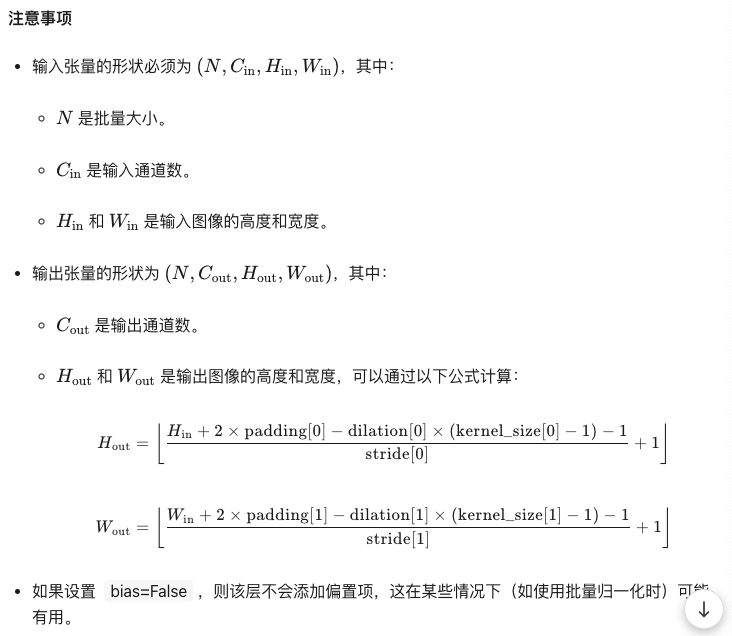

In [3]:
Image(filename='./Image/Conv2d.png',width=600)

## torch.nn.RNN

torch.nn.RNN 是 PyTorch 中用于创建简单循环神经网络（RNN）层的类。
- RNN 是一种用于处理序列数据的神经网络，广泛应用于自然语言处理、时间序列分析等领域。

torch.nn.RNN(input_size, hidden_size, num_layers=1, nonlinearity='tanh', bias=True, batch_first=False, dropout=0.0, bidirectional=False)

参数说明
- input_size：输入特征的维度。
- hidden_size：隐藏层的特征维度。
- num_layers：RNN 的层数，默认为 1。
- nonlinearity：非线性激活函数，可以是 'tanh' 或 'relu'，默认为 'tanh'。
- bias：布尔值，如果为 True，则在 RNN 中使用偏置项；如果为 False，则不使用偏置项。默认为 True。
- batch_first：布尔值，如果为 True，则输入和输出张量的形状为 (batch,seq_len,features)；如果为 False，则形状为 (seq_len,batch,features)。默认为 False。
- dropout：如果非零，则在 RNN 的每层之间添加一个 Dropout 层，除了最后一层。默认为 0.0。
- bidirectional：布尔值，如果为 True，则 RNN 是双向的。默认为 False。

属性
- weight_ih_l0：输入到隐藏层的权重，形状为 (hidden_size,input_size)。
- weight_hh_l0：隐藏层到隐藏层的权重，形状为 (hidden_size,hidden_size)。
- bias_ih_l0：输入到隐藏层的偏置项，形状为 (hidden_size,)。
- bias_hh_l0：隐藏层到隐藏层的偏置项，形状为 (hidden_size,)。

In [6]:
import torch
import torch.nn as nn

# 创建一个简单的 RNN
rnn = nn.RNN(input_size=10, hidden_size=20, num_layers=2, nonlinearity='tanh', batch_first=True)

# 打印 RNN 的权重和偏置
print(rnn)
print("Weight ih_l0 shape:", rnn.weight_ih_l0.shape)  # 输出：torch.Size([20, 10])
print("Weight hh_l0 shape:", rnn.weight_hh_l0.shape)  # 输出：torch.Size([20, 20])
print("Bias ih_l0 shape:", rnn.bias_ih_l0.shape)      # 输出：torch.Size([20])
print("Bias hh_l0 shape:", rnn.bias_hh_l0.shape)      # 输出：torch.Size([20])

RNN(10, 20, num_layers=2, batch_first=True)
Weight ih_l0 shape: torch.Size([20, 10])
Weight hh_l0 shape: torch.Size([20, 20])
Bias ih_l0 shape: torch.Size([20])
Bias hh_l0 shape: torch.Size([20])


In [7]:
import torch
import torch.nn as nn

# 创建一个简单的 RNN
rnn = nn.RNN(input_size=10, hidden_size=20, num_layers=2, nonlinearity='tanh', batch_first=True)

# 创建一个输入张量
input_tensor = torch.randn(3, 5, 10)  # 3 个样本，每个样本 5 个时间步，每个时间步 10 个特征

# 初始化隐藏状态
hidden_state = torch.zeros(2, 3, 20)  # 2 层，3 个样本，每层 20 个隐藏单元

# 进行前向传播
output, hidden = rnn(input_tensor, hidden_state)

# 打印输出张量和隐藏状态
print("Output tensor shape:", output.shape)  # 输出：torch.Size([3, 5, 20])
print("Hidden state shape:", hidden.shape)   # 输出：torch.Size([2, 3, 20])

Output tensor shape: torch.Size([3, 5, 20])
Hidden state shape: torch.Size([2, 3, 20])


## torch.nn.LSTM

torch.nn.LSTM 是 PyTorch 中用于创建长短期记忆网络（LSTM）层的类。LSTM 是一种特殊的循环神经网络（RNN），能够学习长期依赖关系，广泛应用于自然语言处理、时间序列分析等领域。

torch.nn.LSTM(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False, proj_size=0)

参数说明
- input_size：输入特征的维度。
- hidden_size：隐藏层的特征维度。
- num_layers：LSTM 的层数，默认为 1。
- bias：布尔值，如果为 True，则在 LSTM 中使用偏置项；如果为 False，则不使用偏置项。默认为 True。
- batch_first：布尔值，如果为 True，则输入和输出张量的形状为 (batch,seq_len,features)；如果为 -False，则形状为 (seq_len,batch,features)。默认为 False。
- dropout：如果非零，则在 LSTM 的每层之间添加一个 Dropout 层，除了最后一层。默认为 0.0。
- bidirectional：布尔值，如果为 True，则 LSTM 是双向的。默认为 False。
- proj_size：投影层的大小，如果为 0，则不使用投影层。默认为 0。


属性
- weight_ih_l0：输入到隐藏层的权重，形状为 (4×hidden_size,input_size)。
- weight_hh_l0：隐藏层到隐藏层的权重，形状为 (4×hidden_size,hidden_size)。
- bias_ih_l0：输入到隐藏层的偏置项，形状为 (4×hidden_size,)。
- bias_hh_l0：隐藏层到隐藏层的偏置项，形状为 (4×hidden_size,)。

In [8]:
import torch
import torch.nn as nn

# 创建一个简单的 LSTM
lstm = nn.LSTM(input_size=10, hidden_size=20, num_layers=2, batch_first=True)

# 打印 LSTM 的权重和偏置
print("Weight ih_l0 shape:", lstm.weight_ih_l0.shape)  # 输出：torch.Size([80, 10])
print("Weight hh_l0 shape:", lstm.weight_hh_l0.shape)  # 输出：torch.Size([80, 20])
print("Bias ih_l0 shape:", lstm.bias_ih_l0.shape)      # 输出：torch.Size([80])
print("Bias hh_l0 shape:", lstm.bias_hh_l0.shape)      # 输出：torch.Size([80])

Weight ih_l0 shape: torch.Size([80, 10])
Weight hh_l0 shape: torch.Size([80, 20])
Bias ih_l0 shape: torch.Size([80])
Bias hh_l0 shape: torch.Size([80])


In [9]:
import torch
import torch.nn as nn

# 创建一个简单的 LSTM
lstm = nn.LSTM(input_size=10, hidden_size=20, num_layers=2, batch_first=True)

# 创建一个输入张量
input_tensor = torch.randn(3, 5, 10)  # 3 个样本，每个样本 5 个时间步，每个时间步 10 个特征

# 初始化隐藏状态和细胞状态
hidden_state = torch.zeros(2, 3, 20)  # 2 层，3 个样本，每层 20 个隐藏单元
cell_state = torch.zeros(2, 3, 20)    # 2 层，3 个样本，每层 20 个细胞单元

# 进行前向传播
output, (hidden, cell) = lstm(input_tensor, (hidden_state, cell_state))

# 打印输出张量、隐藏状态和细胞状态
print("Output tensor shape:", output.shape)  # 输出：torch.Size([3, 5, 20])
print("Hidden state shape:", hidden.shape)   # 输出：torch.Size([2, 3, 20])
print("Cell state shape:", cell.shape)       # 输出：torch.Size([2, 3, 20])

Output tensor shape: torch.Size([3, 5, 20])
Hidden state shape: torch.Size([2, 3, 20])
Cell state shape: torch.Size([2, 3, 20])


## torch.nn.GRU
torch.nn.GRU 是 PyTorch 中用于创建门控循环单元（GRU）层的类。
- GRU 是一种改进的循环神经网络（RNN），它通过引入更新门（update gate）和重置门（reset gate）来解决传统 RNN 中的梯度消失和梯度爆炸问题。
- GRU 广泛应用于自然语言处理、时间序列分析等领域。

torch.nn.GRU(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False)

参数说明
- input_size：输入特征的维度。
- hidden_size：隐藏层的特征维度。
- num_layers：GRU 的层数，默认为 1。
- bias：布尔值，如果为 True，则在 GRU 中使用偏置项；如果为 False，则不使用偏置项。默认为 True。
- batch_first：布尔值，如果为 True，则输入和输出张量的形状为 (batch,seq_len,features)；如果为 False，则形状为 (seq_len,batch,features)。默认为 False。
- dropout：如果非零，则在 GRU 的每层之间添加一个 Dropout 层，除了最后一层。默认为 0.0。
- bidirectional：布尔值，如果为 True，则 GRU 是双向的。默认为 False。

属性
- weight_ih_l0：输入到隐藏层的权重，形状为 (3×hidden_size,input_size)。
- weight_hh_l0：隐藏层到隐藏层的权重，形状为 (3×hidden_size,hidden_size)。
- bias_ih_l0：输入到隐藏层的偏置项，形状为 (3×hidden_size,)。
- bias_hh_l0：隐藏层到隐藏层的偏置项，形状为 (3×hidden_size,)。

In [1]:
import torch
import torch.nn as nn

# 创建一个简单的 GRU
gru = nn.GRU(input_size=10, hidden_size=20, num_layers=2, batch_first=True)

# 打印 GRU 的权重和偏置
print("Weight ih_l0 shape:", gru.weight_ih_l0.shape)  # 输出：torch.Size([60, 10])
print("Weight hh_l0 shape:", gru.weight_hh_l0.shape)  # 输出：torch.Size([60, 20])
print("Bias ih_l0 shape:", gru.bias_ih_l0.shape)      # 输出：torch.Size([60])
print("Bias hh_l0 shape:", gru.bias_hh_l0.shape)      # 输出：torch.Size([60])

Weight ih_l0 shape: torch.Size([60, 10])
Weight hh_l0 shape: torch.Size([60, 20])
Bias ih_l0 shape: torch.Size([60])
Bias hh_l0 shape: torch.Size([60])


In [2]:
import torch
import torch.nn as nn

# 创建一个简单的 GRU
gru = nn.GRU(input_size=10, hidden_size=20, num_layers=2, batch_first=True)

# 创建一个输入张量
input_tensor = torch.randn(3, 5, 10)  # 3 个样本，每个样本 5 个时间步，每个时间步 10 个特征

# 初始化隐藏状态
hidden_state = torch.zeros(2, 3, 20)  # 2 层，3 个样本，每层 20 个隐藏单元

# 进行前向传播
output, hidden = gru(input_tensor, hidden_state)

# 打印输出张量和隐藏状态
print("Output tensor shape:", output.shape)  # 输出：torch.Size([3, 5, 20])
print("Hidden state shape:", hidden.shape)   # 输出：torch.Size([2, 3, 20])

Output tensor shape: torch.Size([3, 5, 20])
Hidden state shape: torch.Size([2, 3, 20])


# 2. 激活函数（Activation Functions）
激活函数用于引入非线性，使神经网络能够学习复杂的模式。
- torch.nn.ReLU：Rectified Linear Unit（ReLU）激活函数。
- torch.nn.Sigmoid：Sigmoid 激活函数。
- torch.nn.Tanh：Tanh 激活函数。
- torch.nn.Softmax：Softmax 激活函数，常用于多分类问题的输出层。

## torch.nn.ReLU
torch.nn.ReLU 是 PyTorch 中实现 Rectified Linear Unit（ReLU）激活函数的类。
- ReLU 是一种非常流行的激活函数，广泛用于深度学习模型中，尤其是在卷积神经网络（CNN）和全连接网络中。- - ReLU 的主要优点是计算简单且能够缓解梯度消失问题。


ReLU 激活函数的数学定义如下：
- ReLU(x)=max(0,x)
这意味着对于输入 x：
- 如果 x>0，输出为 x。
- 如果 x≤0，输出为 0。

torch.nn.ReLU(inplace=False)
- inplace：布尔值，
  - 如果为 True，则在原地进行操作，不创建新的张量。
  - 默认为 False
  
  
注意事项:
- ReLU 激活函数在训练过程中可能会导致一些神经元“死亡”，即这些神经元的输出始终为 0。这通常是因为梯度为 0，导致这些神经元无法更新。
  - 解决方法可以是使用 Leaky ReLU 或 Parametric ReLU（PReLU）。
- 如果你希望在原地修改输入张量，可以设置 inplace=True，但这会节省内存，同时可能会导致一些不可预测的行为，特别是在多线程环境中。

In [4]:
import torch
import torch.nn as nn

# 创建一个 ReLU 激活函数
relu = nn.ReLU()

# 创建一个输入张量
input_tensor = torch.tensor([-1.0, 0.0, 1.0, 2.0])

# 应用 ReLU 激活函数
output_tensor = relu(input_tensor)

# 打印输出张量
print("Output tensor:", output_tensor)
# 输出：tensor([0., 0., 1., 2.])

Output tensor: tensor([0., 0., 1., 2.])


In [ ]:
import torch
import torch.nn as nn

# 创建一个 ReLU 激活函数
relu = nn.ReLU(inplace=True)

# 创建一个输入张量
input_tensor = torch.tensor([-1.0, 0.0, 1.0, 2.0], requires_grad=True)

# 应用 ReLU 激活函数
relu(input_tensor)

# 打印输入张量（已经被修改）
print("Input tensor after ReLU:", input_tensor)
# 输出：tensor([0., 0., 1., 2.], grad_fn=<ReluBackward0>)

## torch.nn.Sigmoid
torch.nn.Sigmoid 是 PyTorch 中实现 Sigmoid 激活函数的类。
- Sigmoid 函数是一种常用的非线性激活函数，广泛用于神经网络中，尤其是在二分类问题和神经网络的输出层。- - Sigmoid 函数将输入映射到 (0, 1) 区间，因此它常用于表示概率。
- Sigmoid 函数在输入值较大或较小时，梯度接近于 0，这可能导致梯度消失问题。在深层网络中，这可能是一个问题，可以考虑使用其他激活函数，如 ReLU 或 Leaky ReLU。

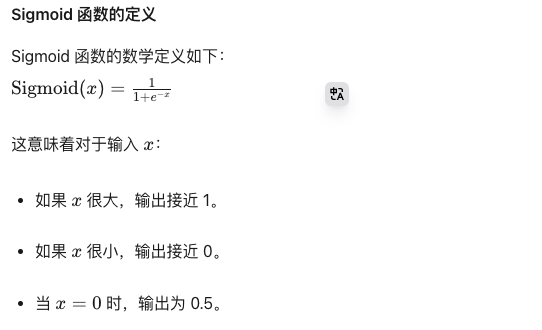

In [7]:
Image(filename='./Image/nn.sigmod.png',width=500)

In [8]:
import torch
import torch.nn as nn

# 创建一个 Sigmoid 激活函数
sigmoid = nn.Sigmoid()

# 创建一个输入张量
input_tensor = torch.tensor([-1.0, 0.0, 1.0, 2.0])

# 应用 Sigmoid 激活函数
output_tensor = sigmoid(input_tensor)

# 打印输出张量
print("Output tensor:", output_tensor)
# 输出：tensor([0.2689, 0.5000, 0.7311, 0.8808])

Output tensor: tensor([0.2689, 0.5000, 0.7311, 0.8808])


## torch.nn.Tanh 

torch.nn.Tanh 是 PyTorch 中实现双曲正切（Tanh）激活函数的类。Tanh 函数是一种常用的非线性激活函数，广泛用于神经网络中。它将输入映射到 (-1, 1) 区间，因此它在某些情况下比 Sigmoid 函数更受欢迎。
- 它将输入值归一化到一个对称的区间。
- Tanh 函数在输入值较大或较小时，梯度接近于 0，这可能导致梯度消失问题。在深层网络中，这可能是一个问题，可以考虑使用其他激活函数，如 ReLU 或 Leaky ReLU。

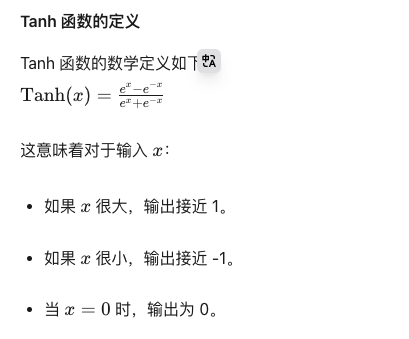

In [9]:
Image(filename='./Image/nn.tanh.png',width=500)

In [10]:
import torch
import torch.nn as nn

# 创建一个 Tanh 激活函数
tanh = nn.Tanh()

# 创建一个输入张量
input_tensor = torch.tensor([-1.0, 0.0, 1.0, 2.0])

# 应用 Tanh 激活函数
output_tensor = tanh(input_tensor)

# 打印输出张量
print("Output tensor:", output_tensor)
# 输出：tensor([-0.7616,  0.0000,  0.7616,  0.9640])

Output tensor: tensor([-0.7616,  0.0000,  0.7616,  0.9640])


## torch.nn.Softmax
torch.nn.Softmax 是 PyTorch 中实现 Softmax 激活函数的类。
- Softmax 函数通常用于多分类问题的输出层，它将输入张量的每个元素映射到 (0, 1) 区间，并确保所有输出值的总和为 1。
- 因此，Softmax 函数的输出可以被解释为概率分布。

In [11]:
import torch
import torch.nn as nn

# 创建一个 Softmax 激活函数
softmax = nn.Softmax(dim=1)

# 创建一个输入张量
input_tensor = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

# 应用 Softmax 激活函数
output_tensor = softmax(input_tensor)

# 打印输出张量
print("Output tensor:", output_tensor)
# 输出：
# tensor([[0.0900, 0.2447, 0.6652],
#         [0.0900, 0.2447, 0.6652]])

Output tensor: tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])


# 3. 损失函数（Loss Functions）

损失函数用于衡量模型的预测值与真实值之间的差异，是训练过程中优化的目标。
- torch.nn.MSELoss：均方误差损失函数。
- torch.nn.CrossEntropyLoss：交叉熵损失函数，常用于分类问题。
- torch.nn.BCELoss：二元交叉熵损失函数，常用于二分类问题。

## torch.nn.MSELoss
torch.nn.MSELoss 是 PyTorch 中实现均方误差（Mean Squared Error, MSE）损失函数的类。
- 均方误差损失函数是回归任务中常用的损失函数之一，它计算预测值和真实值之间的平方差的均值。

torch.nn.MSELoss(size_average=None, reduce=None, reduction='mean')
- size_average：已废弃，不再使用。
- reduce：已废弃，不再使用。
- reduction：指定损失的归约方式，可以是以下几种之一：
  - 'none'：不进行归约，返回每个元素的损失。
  - 'mean'：计算所有元素的平均损失。默认值。
  - 'sum'：计算所有元素的总损失。


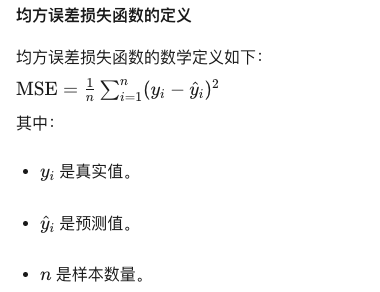

In [13]:
Image(filename='./Image/mse_loss.png',width=500)

In [14]:
import torch
import torch.nn as nn

# 创建一个 MSELoss 损失函数
mse_loss = nn.MSELoss()

# 创建预测值和真实值张量
predictions = torch.tensor([1.0, 2.0, 3.0])
targets = torch.tensor([1.0, 2.0, 5.0])

# 计算损失
loss = mse_loss(predictions, targets)

# 打印损失值
print("Loss:", loss.item())
# 输出：Loss: 1.3333333333333333

Loss: 1.3333333730697632


In [15]:
import torch
import torch.nn as nn

# 创建一个 MSELoss 损失函数
mse_loss_mean = nn.MSELoss(reduction='mean')
mse_loss_sum = nn.MSELoss(reduction='sum')
mse_loss_none = nn.MSELoss(reduction='none')

# 创建预测值和真实值张量
predictions = torch.tensor([1.0, 2.0, 3.0])
targets = torch.tensor([1.0, 2.0, 5.0])

# 计算不同归约方式的损失
loss_mean = mse_loss_mean(predictions, targets)
loss_sum = mse_loss_sum(predictions, targets)
loss_none = mse_loss_none(predictions, targets)

# 打印损失值
print("Loss (mean):", loss_mean.item())  # 输出：Loss (mean): 1.3333333333333333
print("Loss (sum):", loss_sum.item())   # 输出：Loss (sum): 4.0
print("Loss (none):", loss_none)        # 输出：tensor([0., 0., 4.])

Loss (mean): 1.3333333730697632
Loss (sum): 4.0
Loss (none): tensor([0., 0., 4.])


## torch.nn.CrossEntropyLoss

torch.nn.CrossEntropyLoss 是 PyTorch 中实现交叉熵损失函数的类。
- 交叉熵损失函数是分类任务中常用的损失函数之一，尤其适用于多分类问题。
- 它结合了 torch.nn.LogSoftmax 和 torch.nn.NLLLoss（负对数似然损失）的功能，
- 通常用于计算模型输出的概率分布和目标标签之间的差异。

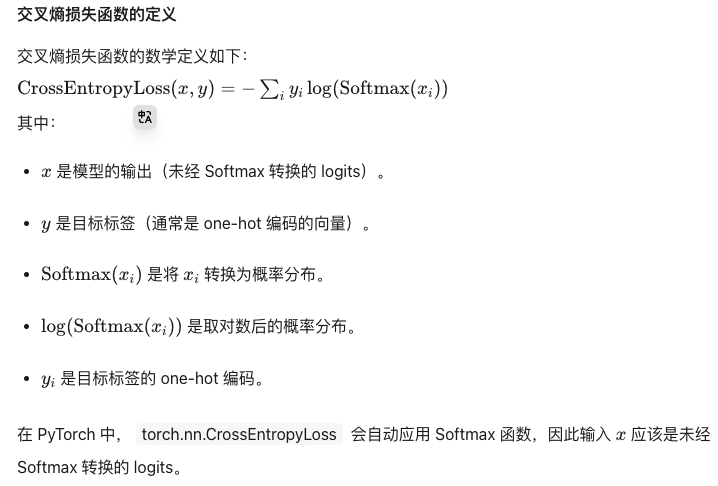

In [16]:
Image(filename='./Image/CEL_loss.png',width=600)

In [17]:
import torch
import torch.nn as nn

# 创建一个 CrossEntropyLoss 损失函数
criterion = nn.CrossEntropyLoss()

# 创建模型的输出（未经 Softmax 转换的 logits）
outputs = torch.tensor([[0.1, 0.2, 0.7], [0.3, 0.6, 0.1]])

# 创建目标标签（类别索引）
targets = torch.tensor([2, 1])

# 计算损失
loss = criterion(outputs, targets)

# 打印损失值
print("Loss:", loss.item())
# 输出：Loss: 0.5044155111312866

Loss: 0.8106180429458618


In [18]:
import torch
import torch.nn as nn

# 创建一个 CrossEntropyLoss 损失函数
criterion_mean = nn.CrossEntropyLoss(reduction='mean')
criterion_sum = nn.CrossEntropyLoss(reduction='sum')
criterion_none = nn.CrossEntropyLoss(reduction='none')

# 创建模型的输出（未经 Softmax 转换的 logits）
outputs = torch.tensor([[0.1, 0.2, 0.7], [0.3, 0.6, 0.1]])

# 创建目标标签（类别索引）
targets = torch.tensor([2, 1])

# 计算不同归约方式的损失
loss_mean = criterion_mean(outputs, targets)
loss_sum = criterion_sum(outputs, targets)
loss_none = criterion_none(outputs, targets)

# 打印损失值
print("Loss (mean):", loss_mean.item())  # 输出：Loss (mean): 0.5044155111312866
print("Loss (sum):", loss_sum.item())   # 输出：Loss (sum): 1.0088310222625732
print("Loss (none):", loss_none)        # 输出：tensor([0.3567, 0.6521])

Loss (mean): 0.8106180429458618
Loss (sum): 1.6212360858917236
Loss (none): tensor([0.7679, 0.8533])


## torch.nn.BCELoss

torch.nn.BCELoss 是 PyTorch 中实现二元交叉熵（Binary Cross-Entropy, BCE）损失函数的类。
- 二元交叉熵损失函数是二分类问题中常用的损失函数，
- 用于衡量模型输出的概率分布和目标标签之间的差异。

二元交叉熵损失函数的数学定义如下：
BCELoss(x,y)=−[y⋅log(x)+(1−y)⋅log(1−x)]
其中：
- x 是模型的输出，通常是一个概率值（范围在 [0, 1] 之间）。
- y 是目标标签，取值为 0 或 1。

In [1]:
import torch
import torch.nn as nn

# 创建一个 BCELoss 损失函数
bce_loss = nn.BCELoss()

# 创建模型的输出（概率值）
outputs = torch.tensor([0.8, 0.4, 0.2])

# 创建目标标签（取值为 0 或 1）
targets = torch.tensor([1.0, 0.0, 1.0])

# 计算损失
loss = bce_loss(outputs, targets)

# 打印损失值
print("Loss:", loss.item())
# 输出：Loss: 0.5138286662154236

Loss: 0.7811357378959656


In [ ]:
import torch
import torch.nn as nn

# 创建一个 BCELoss 损失函数
bce_loss_mean = nn.BCELoss(reduction='mean')
bce_loss_sum = nn.BCELoss(reduction='sum')
bce_loss_none = nn.BCELoss(reduction='none')

# 创建模型的输出（概率值）
outputs = torch.tensor([0.8, 0.4, 0.2])

# 创建目标标签（取值为 0 或 1）
targets = torch.tensor([1.0, 0.0, 1.0])

# 计算不同归约方式的损失
loss_mean = bce_loss_mean(outputs, targets)
loss_sum = bce_loss_sum(outputs, targets)
loss_none = bce_loss_none(outputs, targets)

# 打印损失值
print("Loss (mean):", loss_mean.item())  # 输出：Loss (mean): 0.5138286662154236
print("Loss (sum):", loss_sum.item())   # 输出：Loss (sum): 1.5414859987561035
print("Loss (none):", loss_none)        # 输出：tensor([0.2231, 0.6931, 0.2231])

#  优化器（Optimizers）
优化器用于更新网络的权重，以最小化损失函数。
- torch.optim.SGD：随机梯度下降优化器。
- torch.optim.Adam：Adam 优化器，结合了 Momentum 和 RMSprop 的优点。
- torch.optim.RMSprop：RMSprop 优化器。

## torch.optim.SGD
torch.optim.SGD 是 PyTorch 中实现随机梯度下降（Stochastic Gradient Descent, SGD）优化器的类。SGD 是一种常用的优化算法，广泛用于训练神经网络。
- 它通过迭代更新模型的参数，以最小化损失函数。

torch.optim.SGD(params, lr, momentum=0, dampening=0, weight_decay=0, nesterov=False)

- params：模型的参数，通常是一个参数列表或参数生成器。
- lr：学习率，控制参数更新的步长。
- momentum：动量因子，默认为 0。动量可以帮助加速梯度下降过程，特别是在有噪声的梯度中。
- dampening：阻尼因子，用于动量计算，默认为 0。
- weight_decay：权重衰减因子，默认为 0。权重衰减可以防止模型过拟合。
- nesterov：布尔值，如果为 True，则使用 Nesterov 动量。默认为 False。

- 权重衰减（weight_decay）：权重衰减可以防止模型过拟合，它通过在损失函数中添加一个正则化项来实现。
- Nesterov 动量（nesterov）：Nesterov 动量是一种改进的动量方法，它在计算梯度时考虑了动量的影响，可以进一步加速训练。

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的模型
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 创建模型
model = SimpleNet()

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss
# 动量（momentum）：动量可以帮助加速梯度下降过程，特别是在有噪声的梯度中。动量值通常在 0.9 左右。
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0001)

# 创建一些虚拟数据
inputs = torch.randn(4, 10)  # 4 个样本，每个样本 10 个特征
labels = torch.tensor([0, 1, 0, 1])  # 真实标签

# 训练模型
for epoch in range(100):  # 训练 100 个 epoch
    optimizer.zero_grad()  # 清零梯度
    outputs = model(inputs)  # 前向传播
    loss = criterion(outputs, labels)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6615
Epoch [20/100], Loss: 0.6229
Epoch [30/100], Loss: 0.5821
Epoch [40/100], Loss: 0.5368
Epoch [50/100], Loss: 0.4882
Epoch [60/100], Loss: 0.4420
Epoch [70/100], Loss: 0.4056
Epoch [80/100], Loss: 0.3836
Epoch [90/100], Loss: 0.3712
Epoch [100/100], Loss: 0.3639


## torch.optim.Adam
torch.optim.Adam 是 PyTorch 中实现 Adam 优化器的类。Adam（Adaptive Moment Estimation）是一种非常流行的优化算法，结合了动量（Momentum）和 RMSprop 的优点，适用于训练各种深度学习模型。
- 它通过自适应地调整学习率，能够快速收敛并提高模型的性能。

torch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999), eps=1e-8, weight_decay=0, amsgrad=False)

- params：模型的参数，通常是一个参数列表或参数生成器。
- lr：学习率，控制参数更新的步长。默认值为 0.001。
- betas：两个超参数，用于计算梯度的一阶和二阶矩估计。默认值为 (0.9, 0.999)。
- eps：用于数值稳定性的小常数，防止除以零。默认值为 1e-8。
- weight_decay：权重衰减因子，用于防止过拟合。默认值为 0。
- amsgrad：布尔值，如果为 True，则使用 AMSGrad 变体。默认为 False

- 动量参数（betas）：默认值为 (0.9, 0.999)，通常不需要调整。
- 权重衰减（weight_decay）：权重衰减可以防止模型过拟合，通常设置为 0.0001 或 0.0005。
- AMSGrad（amsgrad）：AMSGrad 是 Adam 的一个变体，适用于某些特定场景。默认为 False，通常不需要启用。


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的模型
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 创建模型
model = SimpleNet()

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

# 创建一些虚拟数据
inputs = torch.randn(4, 10)  # 4 个样本，每个样本 10 个特征
labels = torch.tensor([0, 1, 0, 1])  # 真实标签

# 训练模型
for epoch in range(100):  # 训练 100 个 epoch
    optimizer.zero_grad()  # 清零梯度
    outputs = model(inputs)  # 前向传播
    loss = criterion(outputs, labels)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6352
Epoch [20/100], Loss: 0.6161
Epoch [30/100], Loss: 0.5968
Epoch [40/100], Loss: 0.5764
Epoch [50/100], Loss: 0.5551
Epoch [60/100], Loss: 0.5328
Epoch [70/100], Loss: 0.5099
Epoch [80/100], Loss: 0.4863
Epoch [90/100], Loss: 0.4624
Epoch [100/100], Loss: 0.4384


## torch.optim.RMSprop

torch.optim.RMSprop 是 PyTorch 中实现 RMSprop 优化器的类。
- RMSprop（Root Mean Square Propagation）是一种自适应学习率的优化算法，特别适用于处理非稳态（non-stationary）目标和具有不同更新频率的参数。
- 它通过调整每个参数的学习率，使其在不同方向上的更新速度更加均匀，从而加速训练过程并提高模型的性能。

torch.optim.RMSprop(params, lr=0.001, alpha=0.99, eps=1e-8, weight_decay=0, momentum=0, centered=False)

- params：模型的参数，通常是一个参数列表或参数生成器。
- lr：学习率，控制参数更新的步长。默认值为 0.001。
- alpha：平滑系数，用于计算平方梯度的加权平均值。默认值为 0.99。
- eps：用于数值稳定性的小常数，防止除以零。默认值为 1e-8。
- weight_decay：权重衰减因子，用于防止过拟合。默认值为 0。
- momentum：动量因子，用于加速梯度下降过程。默认值为 0。
- centered：布尔值，如果为 True，则计算梯度的中心化 RMSprop。默认为 False。

- 平滑系数（alpha）：默认值为 0.99，通常不需要调整。
- 权重衰减（weight_decay）：权重衰减可以防止模型过拟合，通常设置为 0.0001 或 0.0005。
- 动量（momentum）：动量可以帮助加速梯度下降过程，特别是在有噪声的梯度中。默认值为 0，可以根据需要启用。
- 中心化（centered）：如果启用中心化，RMSprop 会计算梯度的中心化版本，这可以进一步提高稳定性。默认为 False。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的模型
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 创建模型
model = SimpleNet()

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001, weight_decay=0.0001)

# 创建一些虚拟数据
inputs = torch.randn(4, 10)  # 4 个样本，每个样本 10 个特征
labels = torch.tensor([0, 1, 0, 1])  # 真实标签

# 训练模型
for epoch in range(100):  # 训练 100 个 epoch
    optimizer.zero_grad()  # 清零梯度
    outputs = model(inputs)  # 前向传播
    loss = criterion(outputs, labels)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.7001
Epoch [20/100], Loss: 0.6517
Epoch [30/100], Loss: 0.6153
Epoch [40/100], Loss: 0.5866
Epoch [50/100], Loss: 0.5628
Epoch [60/100], Loss: 0.5423
Epoch [70/100], Loss: 0.5240
Epoch [80/100], Loss: 0.5080
Epoch [90/100], Loss: 0.4932
Epoch [100/100], Loss: 0.4801


## torch.optim.Adagrad
torch.optim.Adagrad 是 PyTorch 中实现 Adagrad 优化器的类。
- Adagrad（Adaptive Gradient Algorithm）是一种自适应学习率的优化算法，
- 特别适用于处理稀疏数据，如自然语言处理和计算机视觉中的某些任务。
- Adagrad 通过为每个参数维护一个学习率，根据参数的历史梯度动态调整学习率，从而提高训练的效率和稳定性。

torch.optim.Adagrad(params, lr=0.01, lr_decay=0, weight_decay=0, initial_accumulator_value=0)

- params：模型的参数，通常是一个参数列表或参数生成器。
- lr：学习率，控制参数更新的步长。默认值为 0.01。
- lr_decay：学习率衰减率，默认值为 0。在每次参数更新后，学习率会按照这个衰减率逐渐减小。
- weight_decay：权重衰减因子，用于防止过拟合。默认值为 0。
- initial_accumulator_value：初始的累加器值，用于初始化 Adagrad 的累积梯度平方。默认值为 0。

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的模型
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 创建模型
model = SimpleNet()

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adagrad(model.parameters(), lr=0.01, weight_decay=0.0001)

# 创建一些虚拟数据
inputs = torch.randn(4, 10)  # 4 个样本，每个样本 10 个特征
labels = torch.tensor([0, 1, 0, 1])  # 真实标签

# 训练模型
for epoch in range(100):  # 训练 100 个 epoch
    optimizer.zero_grad()  # 清零梯度
    outputs = model(inputs)  # 前向传播
    loss = criterion(outputs, labels)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

##

torch.optim.Adadelta 是 PyTorch 中实现 Adadelta 优化器的类。
- Adadelta 是一种自适应学习率的优化算法，它改进了 Adagrad 的一些限制，特别是在处理非稳态目标和具有不同更新频率的参数时。
- Adadelta 通过维护一个梯度的滑动窗口来动态调整学习率，从而提高训练的效率和稳定性。

torch.optim.Adadelta(params, lr=1.0, rho=0.9, eps=1e-6, weight_decay=0)

- params：模型的参数，通常是一个参数列表或参数生成器。
- lr：学习率，控制参数更新的步长。默认值为 1.0。
- rho：衰减率，用于计算梯度的滑动窗口的平均值。默认值为 0.9。
- eps：用于数值稳定性的小常数，防止除以零。默认值为 1e-6。
- weight_decay：权重衰减因子，用于防止过拟合。默认值为 0

- 衰减率（rho）：衰减率用于计算梯度的滑动窗口的平均值。默认值为 0.9，通常不需要调整。
- 数值稳定性常数（eps）：用于数值稳定性的小常数，防止除以零。默认值为 1e-6，通常不需要调整。
- 权重衰减（weight_decay）：权重衰减可以防止模型过拟合，通常设置为 0.0001 或 0.0005。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的模型
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 创建模型
model = SimpleNet()

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adadelta(model.parameters(), lr=1.0, rho=0.9, eps=1e-6, weight_decay=0.0001)

# 创建一些虚拟数据
inputs = torch.randn(4, 10)  # 4 个样本，每个样本 10 个特征
labels = torch.tensor([0, 1, 0, 1])  # 真实标签

# 训练模型
for epoch in range(100):  # 训练 100 个 epoch
    optimizer.zero_grad()  # 清零梯度
    outputs = model(inputs)  # 前向传播
    loss = criterion(outputs, labels)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6153
Epoch [20/100], Loss: 0.5287
Epoch [30/100], Loss: 0.4124
Epoch [40/100], Loss: 0.3220
Epoch [50/100], Loss: 0.2598
Epoch [60/100], Loss: 0.2142
Epoch [70/100], Loss: 0.1804
Epoch [80/100], Loss: 0.1543
Epoch [90/100], Loss: 0.1337
Epoch [100/100], Loss: 0.1170
